In [1]:
import os
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import plotly.graph_objects as go
import plotly.colors as pc
from collections import Counter
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy as scipy_entropy

In [2]:


# --------------------------------------------------
# Style
# --------------------------------------------------

sns.set_style("white")
sns.set_context("talk")


# --------------------------------------------------
# File paths
# --------------------------------------------------

mouse_files = {
    "DLS Inhibition Mouse (Complete)": r"X:\3darena_chemogenetic\c1_041626\042126_m2_dls\cluster_output_042126_m2_dls_+washoff\Combined_Results\Results\test1\Cluster_detail_results.csv",
}



In [5]:

# --------------------------------------------------
# Load + label data
# --------------------------------------------------

def load_mouse_data(file_path, mouse_name):
    df = pd.read_csv(file_path)

    df = df[["ClusterIdx", "Timestamp", "Folder_Name"]].copy()
    df = df.dropna(subset=["ClusterIdx", "Timestamp", "Folder_Name"])
    df["Folder_Name"] = df["Folder_Name"].replace({
        1.0: "Baseline",
        2.0: "Inhibition",
    })

    df["ClusterIdx"] = pd.to_numeric(df["ClusterIdx"], errors="coerce")
    df["Timestamp"] = pd.to_numeric(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["ClusterIdx", "Timestamp"])

    df["ClusterIdx"] = df["ClusterIdx"].astype(int)
    df["Folder_Name"] = df["Folder_Name"].astype(str).str.strip()
    df["Mouse"] = mouse_name

    folder = df["Folder_Name"].str.lower()
    print(df["Folder_Name"].unique())
    df["Arena"] = np.select(
        [
            folder.str.contains("baseline", na=False),
            folder.str.contains("inhibition", na=False),
            folder.str.contains("washoff", na=False)
        ],
        [
            "Baseline",
            "Inhibition",
            "Washoff"
        ],
        default="Unknown"
    )

    df = df.sort_values(["Folder_Name", "Timestamp"]).reset_index(drop=True)
    return df


# --------------------------------------------------
# Load all mice
# --------------------------------------------------

all_dfs = []

for mouse_name, file_path in mouse_files.items():
    df_mouse = load_mouse_data(file_path, mouse_name)
    all_dfs.append(df_mouse)

df_all = pd.concat(all_dfs, ignore_index=True)

print("\n================ DATA CHECK ================\n")
print("Total rows:", len(df_all))
print("Clusters:", df_all["ClusterIdx"].nunique())

print("\nArena counts:")
print(df_all["Arena"].value_counts())

print("\nArena by mouse:")
print(df_all.groupby(["Mouse", "Arena"]).size())


<StringArray>
['1_baseline', '2_inhibition', '3_washoff']
Length: 3, dtype: str

================ DATA CHECK ================

Total rows: 41568
Clusters: 59

Arena counts:
Arena
Inhibition    17701
Baseline      11947
Washoff       11920
Name: count, dtype: int64

Arena by mouse:
Mouse                            Arena     
DLS Inhibition Mouse (Complete)  Baseline      11947
                                 Inhibition    17701
                                 Washoff       11920
dtype: int64


In [6]:
all_dfs

[       ClusterIdx   Timestamp Folder_Name                            Mouse  \
 0               1    686.4304  1_baseline  DLS Inhibition Mouse (Complete)   
 1               1    686.7302  1_baseline  DLS Inhibition Mouse (Complete)   
 2               1    687.0299  1_baseline  DLS Inhibition Mouse (Complete)   
 3               1    687.3296  1_baseline  DLS Inhibition Mouse (Complete)   
 4               2    687.6294  1_baseline  DLS Inhibition Mouse (Complete)   
 ...           ...         ...         ...                              ...   
 41563          36  14790.6577   3_washoff  DLS Inhibition Mouse (Complete)   
 41564          19  14791.0227   3_washoff  DLS Inhibition Mouse (Complete)   
 41565          48  14791.3677   3_washoff  DLS Inhibition Mouse (Complete)   
 41566          29  14791.7127   3_washoff  DLS Inhibition Mouse (Complete)   
 41567          36  14792.0577   3_washoff  DLS Inhibition Mouse (Complete)   
 
           Arena  
 0      Baseline  
 1      Base

In [7]:


# --------------------------------------------------
# Transition helpers
# --------------------------------------------------

def create_transitions(data, include_self_transitions=False):
    transitions = Counter()

    data = data.sort_values("Timestamp")
    clusters = data["ClusterIdx"].to_numpy()

    if len(clusters) < 2:
        return transitions

    for i in range(len(clusters) - 1):
        c1 = clusters[i]
        c2 = clusters[i + 1]

        if not include_self_transitions and c1 == c2:
            continue

        transitions[(c1, c2)] += 1

    return transitions


def pooled_transitions(df, include_self_transitions=False):
    total = Counter()

    for _, session_df in df.groupby("Folder_Name"):
        total.update(
            create_transitions(
                session_df,
                include_self_transitions=include_self_transitions
            )
        )

    return dict(total)


def transitions_to_matrix(transitions, cluster_list):
    mat = pd.DataFrame(
        0,
        index=cluster_list,
        columns=cluster_list,
        dtype=float
    )

    for (c1, c2), count in transitions.items():
        if c1 in mat.index and c2 in mat.columns:
            mat.loc[c1, c2] = count

    return mat


def normalize(mat):
    row_sums = mat.sum(axis=1).replace(0, np.nan)
    return mat.div(row_sums, axis=0).fillna(0)


def transition_probability_dict(transitions):
    total = sum(transitions.values())

    if total == 0:
        return {}

    return {
        transition: count / total
        for transition, count in transitions.items()
    }


In [8]:

# --------------------------------------------------
# 4F Shared-Motif-Only Heatmaps
# Separate figures
# --------------------------------------------------

def get_shared_transition_mats(trans_a, trans_b):
    shared = set(trans_a.keys()).intersection(set(trans_b.keys()))

    if len(shared) == 0:
        return None, None

    shared_a = {k: trans_a[k] for k in shared}
    shared_b = {k: trans_b[k] for k in shared}

    clusters = sorted(set([c for pair in shared for c in pair]))

    mat_a = normalize(transitions_to_matrix(shared_a, clusters))
    mat_b = normalize(transitions_to_matrix(shared_b, clusters))

    return mat_a, mat_b


def plot_single_shared_heatmap(mat, title):
    plt.figure(figsize=(10, 8))

    if mat is None or mat.empty:
        plt.text(
            0.5,
            0.5,
            "No shared motifs",
            ha="center",
            va="center",
            fontsize=16
        )
        plt.title(title)
        plt.axis("off")
        plt.tight_layout()
        plt.show()
        return

    vmax = mat.to_numpy().max()

    if vmax == 0:
        vmax = 1

    cmap = sns.light_palette("blue", as_cmap=True)

    sns.heatmap(mat, cmap=cmap, vmin=0, vmax=vmax)
    plt.title(title)
    plt.xlabel("To Cluster")
    plt.ylabel("From Cluster")
    plt.tight_layout()
    plt.show()

In [9]:

def plot_4f_shared_heatmaps_for_mouse(df_mouse, mouse_name):
    df_flat = df_mouse[df_mouse["Arena"] == "Baseline"].copy()
    flat_trans = pooled_transitions(df_flat, include_self_transitions=False)

    comparisons = [
        ("Inhibition", df_mouse[df_mouse["Arena"] == "Inhibition"].copy()),
        ("Washoff", df_mouse[df_mouse["Arena"] == "Washoff"].copy()),
    ]

    for label, df_group in comparisons:
        print(f"\nMaking 4F shared heatmaps for {mouse_name}: Baseline vs {label}")

        group_trans = pooled_transitions(df_group, include_self_transitions=False)

        group_mat, flat_mat = get_shared_transition_mats(
            group_trans,
            flat_trans
        )

        plot_single_shared_heatmap(
            group_mat,
            f"4F {mouse_name}: Baseline vs {label} - {label} Shared-Motif Heatmap"
        )

        plot_single_shared_heatmap(
            flat_mat,
            f"4F {mouse_name}: Baseline vs {label} - Flat Shared-Motif Heatmap"
        )



In [10]:

# --------------------------------------------------
# Jensen-Shannon Divergence
# --------------------------------------------------

def transitions_to_prob_vector(transitions, all_keys):
    total = sum(transitions.values())

    if total == 0:
        return np.zeros(len(all_keys))

    return np.array([
        transitions.get(k, 0) / total
        for k in all_keys
    ])


def compute_js_divergence(trans_a, trans_b):
    all_keys = list(set(trans_a.keys()).union(set(trans_b.keys())))

    if len(all_keys) == 0:
        print("List 'all_keys' has a length of 0")
        return np.nan

    p = transitions_to_prob_vector(trans_a, all_keys)
    q = transitions_to_prob_vector(trans_b, all_keys)

    js_distance = jensenshannon(p, q)
    js_divergence = js_distance ** 2

    return js_divergence


def compute_transition_entropy(transitions):
    """Shannon entropy (bits) of the transition probability distribution."""
    total = sum(transitions.values())
    if total == 0:
        return np.nan
    probs = np.array(list(transitions.values())) / total
    return scipy_entropy(probs, base=2)  # bits; drop base=2 for nats

# --------------------------------------------------
# Compute JS divergence by mouse
# --------------------------------------------------

js_rows = []
entropy_rows = []

arena_order = ["Baseline", "Inhibition", "Washoff"]

for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()

    # --- pool transitions per arena ---
    arena_trans = {}
    for arena in arena_order:
        df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
        if not df_arena.empty:
            arena_trans[arena] = pooled_transitions(df_arena, include_self_transitions=False)

    # --- JS divergence for all pairs ---
    comparisons = [
        ("Baseline", "Inhibition"),
        ("Washoff", "Inhibition"),
        ("Baseline", "Washoff"),
    ]
    for arena_a, arena_b in comparisons:
        if arena_a in arena_trans and arena_b in arena_trans:
            js_rows.append({
                "Mouse":        mouse_name,
                "Comparison":   f"{arena_a} vs {arena_b}",
                "JS Divergence": compute_js_divergence(arena_trans[arena_a], arena_trans[arena_b])
            })

    # --- entropy per arena ---
    for arena in arena_order:
        if arena in arena_trans:
            entropy_rows.append({
                "Mouse":          mouse_name,
                "Arena":          arena,
                "Entropy (bits)": compute_transition_entropy(arena_trans[arena])
            })

df_js      = pd.DataFrame(js_rows)
df_entropy = pd.DataFrame(entropy_rows)

print("\n================ JS DIVERGENCE TABLE ================\n")
print(df_js)

print("\n================ ENTROPY TABLE ================\n")
print(df_entropy)


================ JS DIVERGENCE TABLE ================

                             Mouse              Comparison  JS Divergence
0  DLS Inhibition Mouse (Complete)  Baseline vs Inhibition       0.167387
1  DLS Inhibition Mouse (Complete)   Washoff vs Inhibition       0.081908
2  DLS Inhibition Mouse (Complete)     Baseline vs Washoff       0.133460

================ ENTROPY TABLE ================

                             Mouse       Arena  Entropy (bits)
0  DLS Inhibition Mouse (Complete)    Baseline       10.075802
1  DLS Inhibition Mouse (Complete)  Inhibition       10.333865
2  DLS Inhibition Mouse (Complete)     Washoff       10.275944


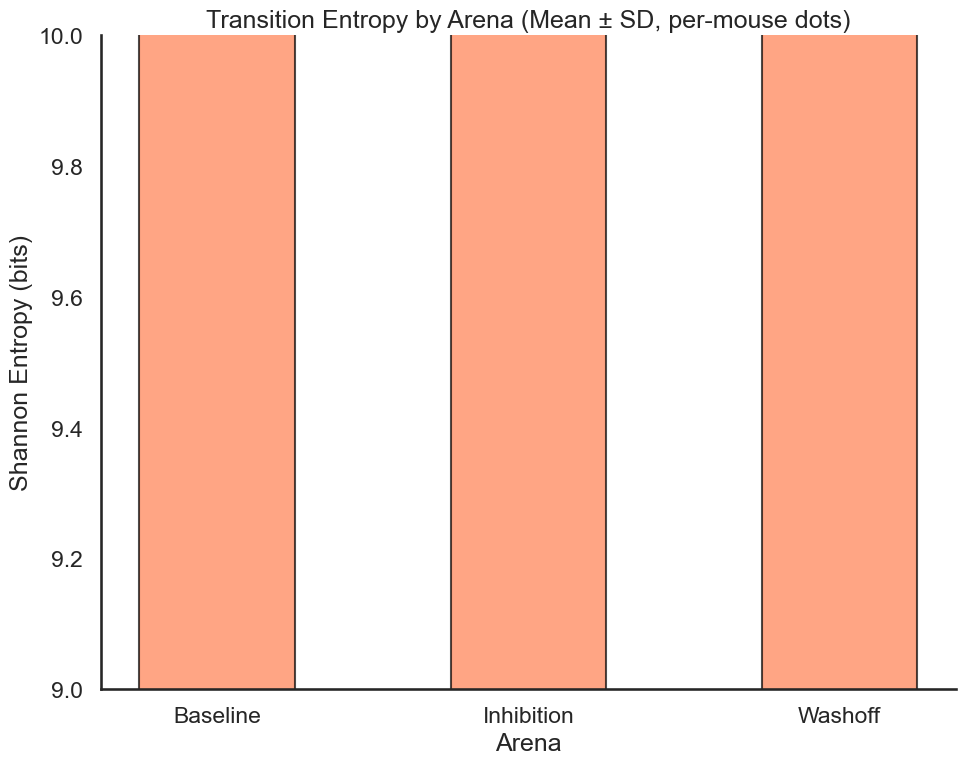

In [11]:

arena_order_plot = ["Baseline", "Inhibition", "Washoff"]

# Filter to only arenas that exist in the data
existing_arenas = df_entropy["Arena"].unique()
plot_order = [a for a in arena_order_plot if a in existing_arenas]

plt.figure(figsize=(10, 8))
ax = plt.gca()

# --- Bar: group mean ---
df_grouped = df_entropy.groupby("Arena")["Entropy (bits)"].agg(["mean", "std"]).reindex(plot_order)

x_pos = np.arange(len(plot_order))
bar_width = 0.5

ax.bar(
    x_pos,
    df_grouped["mean"],
    width=bar_width,
    color="coral",
    edgecolor="black",
    linewidth=1.5,
    alpha=0.7,
    zorder=2
)

# --- Error bars: std ---
# ax.errorbar(
#     x_pos,
#     df_grouped["mean"],
#     yerr=df_grouped["std"],
#     fmt="none",
#     color="black",
#     capsize=5,
#     linewidth=1.5,
#     zorder=3
# )

# --- Dots: individual mice ---
mice = df_entropy["Mouse"].unique()
colors = sns.color_palette("tab10", n_colors=len(mice))
mouse_color = dict(zip(mice, colors))

# for arena_idx, arena in enumerate(plot_order):
#     df_arena = df_entropy[df_entropy["Arena"] == arena]
#     for _, row in df_arena.iterrows():
#         ax.scatter(
#             arena_idx,
#             row["Entropy (bits)"],
#             color=mouse_color[row["Mouse"]],
#             s=80,
#             zorder=4,
#             edgecolors="white",
#             linewidths=0.5
#         )

# # --- Legend for mice ---
# handles = [
#     plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=mouse_color[m],
#                markersize=9, label=m)
#     for m in mice
# ]
# ax.legend(handles=handles, title="Mouse", bbox_to_anchor=(1.01, 1), loc="upper left")

ax.set_xticks(x_pos)
ax.set_xticklabels(plot_order)
                   #, rotation=45, ha="right")
ax.set_xlabel("Arena")
ax.set_ylabel("Shannon Entropy (bits)")
ax.set_title("Transition Entropy by Arena (Mean ± SD, per-mouse dots)")
ax.set_ylim(9,10)
sns.despine()
plt.tight_layout()
plt.savefig("transition_entropy_by_arena.png", dpi=300)
plt.show()

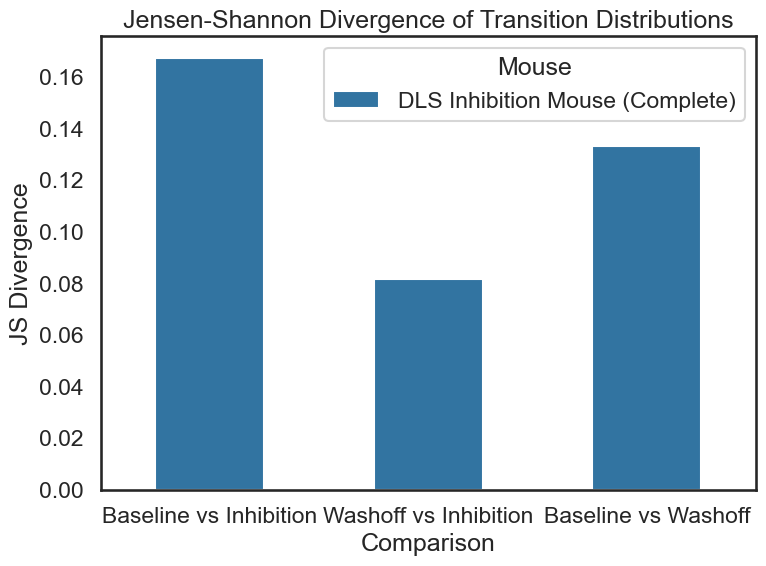

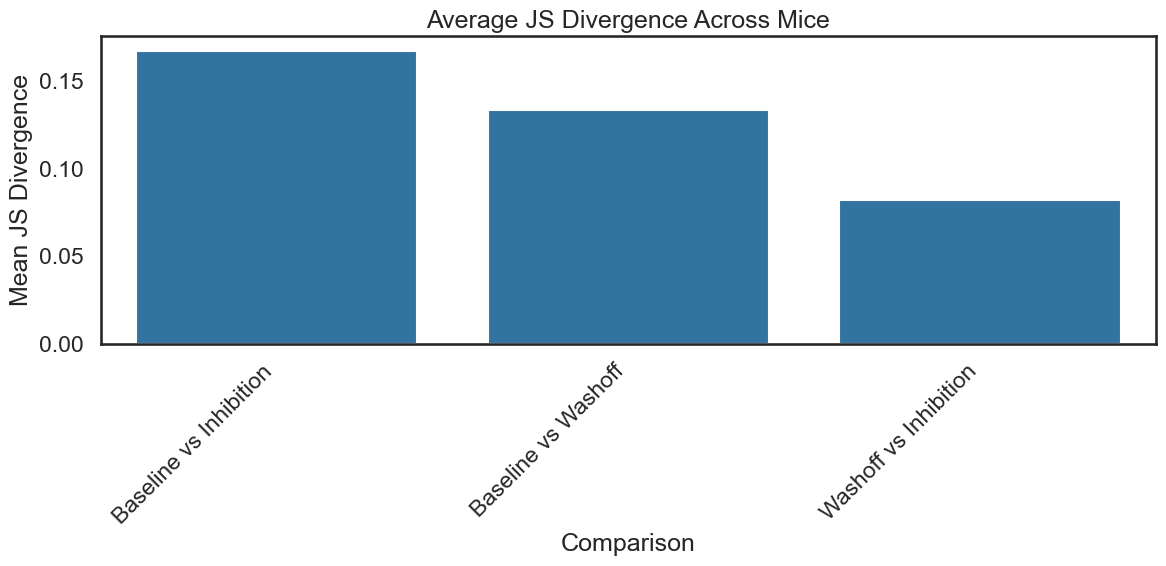

In [12]:
# --------------------------------------------------
# JS divergence bar graph by mouse
# --------------------------------------------------

plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_js,
    width=.5,
    x="Comparison",
    y="JS Divergence",
    hue="Mouse"
)

plt.title("Jensen-Shannon Divergence of Transition Distributions")
plt.xlabel("Comparison")
plt.ylabel("JS Divergence")
#plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(r"JS Divergence of Transition Distributions.png", dpi=300)
plt.show()


# --------------------------------------------------
# Average JS divergence across mice
# --------------------------------------------------

df_js_avg = (
    df_js
    .groupby("Comparison", as_index=False)["JS Divergence"]
    .mean()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_js_avg,
    x="Comparison",
    y="JS Divergence"
)

plt.title("Average JS Divergence Across Mice")
plt.xlabel("Comparison")
plt.ylabel("Mean JS Divergence")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
def plot_transition_graph(
    subset_transition_matrix,
    transitions=40,
    node_scaling=4,
    edge_scaling=6,
    text_scaling=0.4,
    arrow_reduction_factor=0.03,
    title="Transition Graph",
    colorscale="Blues",
    save=False,
    path=None,
    export_csv=False,
    csv_path=None
):
    import plotly.colors as pc

    def weight_to_color(w, vmin, vmax):
        if vmax == vmin:
            return "rgb(8,48,107)"
        norm = (w - vmin) / (vmax - vmin)
        return pc.sample_colorscale(colorscale, norm)[0]

    edges = []

    for i in subset_transition_matrix.index:
        for j in subset_transition_matrix.columns:
            weight = subset_transition_matrix.loc[i, j]
            if weight > 0 and i != j:
                edges.append((str(i), str(j), float(weight)))

    if len(edges) == 0:
        print(f"No nonzero transitions found for: {title}")
        return

    top_edges = sorted(edges, key=lambda x: x[2], reverse=True)[:transitions]

    top_nodes = set(
        [u for u, v, w in top_edges]
        + [v for u, v, w in top_edges]
    )

    G = nx.DiGraph()
    G.add_nodes_from(top_nodes)

    for u, v, w in top_edges:
        G.add_edge(u, v, weight=w)

    if G.number_of_nodes() == 0:
        print(f"No graph created for: {title}")
        return

    ordered_nodes = sorted(G.nodes(), key=lambda x: int(float(x)))
    pos = nx.circular_layout(ordered_nodes)

    node_degrees = dict(G.degree())
    node_size = [48 for node in G.nodes()]
    text_size = [18 for node in G.nodes()]
    pixel_to_coord = 2.4 / 800

    node_radius = [
        size * pixel_to_coord * 0.5
        for size in node_size
    ]

    node_radii = {
        node: r
        for node, r in zip(G.nodes(), node_radius)
    }

    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    vmin_w = min(edge_weights)
    vmax_w = max(edge_weights)

    node_degrees = dict(G.degree())
    degree_values = [node_degrees[node] for node in G.nodes()]

    node_trace = go.Scatter(
        x=[pos[node][0] for node in G.nodes()],
        y=[pos[node][1] for node in G.nodes()],
        text=[str(int(float(node))) for node in G.nodes()],
        mode="markers+text",
        hoverinfo="text",
        marker=dict(
            size=48,
            color=degree_values,
            colorscale=[
                [0.0, "rgb(255,245,240)"],
                [1.0, "rgb(186, 25, 6)"]
            ],
            showscale=True,
            colorbar=dict(
                title="Degree",
                x=1.02,          # position of the degree colorbar
                xanchor="left",
                thickness=15,
                len=0.5,
                y=0.5,
                yanchor="middle"
            ),
            cmin=0,
            cmax=10,
            line=dict(width=1, color="black")
        ),
        textfont=dict(size=18, color="black")
    )

    # --- dummy trace for the Blues (edge weight) colorbar ---
    weight_colorbar_trace = go.Scatter(
        x=[None],
        y=[None],
        mode="markers",
        marker=dict(
            color=[vmin_w, vmax_w],
            colorscale=colorscale,
            showscale=True,
            colorbar=dict(
                title="Weight",
                x=1.12,          # offset to the right of the Degree colorbar
                xanchor="left",
                thickness=15,
                len=0.5,
                y=0.5,
                yanchor="middle"
            ),
            cmin=vmin_w,
            cmax=vmax_w,
        ),
        hoverinfo="none"
    )

    edge_traces = []

    for u, v in sorted(G.edges(), key=lambda e: G[e[0]][e[1]]["weight"]):
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        edge_weight = G[u][v]["weight"]
        color = weight_to_color(edge_weight, vmin_w, vmax_w)

        dx = x1 - x0
        dy = y1 - y0
        dist = np.sqrt(dx * dx + dy * dy)

        if dist == 0:
            continue

        x_start = x0 + dx * (node_radii[u] / dist)
        y_start = y0 + dy * (node_radii[u] / dist)
        x_end   = x1 - dx * (node_radii[v] / dist) - dx * arrow_reduction_factor
        y_end   = y1 - dy * (node_radii[v] / dist) - dy * arrow_reduction_factor

        edge_traces.append(
            go.Scatter(
                x=[x_start, x_end, None],
                y=[y_start, y_end, None],
                line=dict(width=2, color=color),
                hoverinfo="text",
                text=[f"{u} → {v}<br>p={edge_weight:.3f}"],
                mode="lines"
            )
        )

    # --- add weight_colorbar_trace alongside existing traces ---
    fig = go.Figure(data=[*edge_traces, node_trace, weight_colorbar_trace])

    for u, v in sorted(G.edges(), key=lambda e: G[e[0]][e[1]]["weight"]):
        x0, y0 = pos[u]
        x1, y1 = pos[v]

        edge_weight = G[u][v]["weight"]
        color = weight_to_color(edge_weight, vmin_w, vmax_w)

        dx = x1 - x0
        dy = y1 - y0
        dist = (dx ** 2 + dy ** 2) ** 0.5

        x1_arrow = x1 - dx * arrow_reduction_factor if dist > 0 else x1
        y1_arrow = y1 - dy * arrow_reduction_factor if dist > 0 else y1

        fig.add_annotation(
            ax=x0, ay=y0,
            x=x1_arrow, y=y1_arrow,
            xref="x", yref="y",
            axref="x", ayref="y",
            showarrow=True,
            arrowhead=2,
            arrowsize=0.8,
            arrowwidth=2,
            arrowcolor=color
        )

    fig.update_layout(
        title={"text": title, "font": {"size": 16}},
        width=1000,   # slightly wider to accommodate both colorbars
        height=900,
        paper_bgcolor="#d9dde3",
        plot_bgcolor="#d9dde3",
        showlegend=False,
        hovermode="closest",
        margin=dict(b=10, l=10, r=120, t=40),  # extra right margin for colorbars
        xaxis=dict(
            range=[-1.15, 1.15],
            showgrid=False, zeroline=False, showticklabels=False
        ),
        yaxis=dict(
            range=[-1.15, 1.15],
            scaleanchor="x", scaleratio=1,
            showgrid=False, zeroline=False, showticklabels=False
        )
    )

    if save and path:
        base_path, _ = os.path.splitext(path)
        fig.write_image(f"{base_path}.png")
        fig.write_image(f"{base_path}.svg")

    if export_csv and csv_path:
        node_sizes = {
            node: max(node_degrees[node] * node_scaling + 18, 18)
            for node in G.nodes()
        }
        with open(csv_path, mode="w", newline="") as csvfile:
            csvwriter = csv.writer(csvfile)
            csvwriter.writerow(["starting cluster", "ending cluster", "edge weight", "node size"])
            for u, v, w in top_edges:
                node_size_u = node_sizes.get(u, 18)
                csvwriter.writerow([u, v, w, node_size_u])
        print(f"CSV file '{csv_path}' has been created with {len(top_edges)} edges.")

    fig.show()

In [14]:
def plot_combined_shared_transition_graphs(df_mouse, mouse_name, graph_top_n=40, save=False):
    """
    Three transition graphs using all transitions present in ANY arena in the group:
      - Combined: all 5 arenas (Restricted, Non-restricted, Low, Medium, High)
      - 2D:       Restricted + Non-restricted
      - 3D:       Low + Medium + High
    Edge weights reflect combined frequency across the relevant arenas.
    """

    arena_groups = {
        "Combined": ["Baseline", "Inhibition", "Washoff"],
        "Baseline": ["Baseline"],
        "Inhibition":   ["Inhibition"],
        "Washoff": ["Washoff"]
    }

    # --- get per-arena transitions ---
    arena_trans = {}
    for arena in ["Baseline", "Inhibition", "Washoff"]:
        df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
        arena_trans[arena] = pooled_transitions(df_arena, include_self_transitions=False)

    for group_label, arenas in arena_groups.items():

        # --- union: all transitions present in ANY arena in the group ---
        trans_sets = [set(arena_trans[a].keys()) for a in arenas]
        all_keys = set.union(*trans_sets)

        if len(all_keys) == 0:
            print(f"No transitions found for {mouse_name} - {group_label}")
            continue

        # --- combined counts across all arenas in the group ---
        combined_counts = Counter()
        for arena in arenas:
            for k in all_keys:
                combined_counts[k] += arena_trans[arena].get(k, 0)

        # --- normalize to get probabilities ---
        total = sum(combined_counts.values())
        combined_trans = {k: v / total for k, v in combined_counts.items()}

        # --- build matrix ---
        clusters = sorted(set(c for pair in all_keys for c in pair))
        mat = pd.DataFrame(0.0, index=clusters, columns=clusters)

        for (c1, c2), w in combined_trans.items():
            mat.loc[c1, c2] = w

        # --- rescale weights to [0, 1] so edge thickness variation is visible ---
        vals = mat.values
        vmin, vmax = vals.min(), vals.max()

        if vmax > vmin:
            mat = (mat - vmin) / (vmax - vmin)
        else:
            print(f"All edge weights identical for {mouse_name} - {group_label}, skipping rescale")

        print(f"\n{mouse_name} - {group_label}: {len(all_keys)} transitions")

        title=f"{mouse_name}-{group_label} Shared Transition Graph"
        plot_transition_graph(
            mat,
            transitions=graph_top_n,
            title=title,
            save=save,
            path=f"{title.replace(' ', '_')}"
        )

In [15]:
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_combined_shared_transition_graphs(df_mouse, mouse_name, graph_top_n=40, save=True)
    break


DLS Inhibition Mouse (Complete) - Combined: 2417 transitions



DLS Inhibition Mouse (Complete) - Baseline: 1643 transitions



DLS Inhibition Mouse (Complete) - Inhibition: 2106 transitions



DLS Inhibition Mouse (Complete) - Washoff: 1850 transitions


In [16]:
def plot_3d_vs_2d_top_transitions(df_mouse, mouse_name, top_n=10, reference="Baseline", save=False, path=None):
    """
    Gets top N transitions from the reference condition, then plots those same
    transitions for all other conditions side by side.

    Any of the three arenas (Baseline, Inhibition, Washoff) can be the reference.
    The remaining two are plotted as comparison bars.

    Parameters
    ----------
    reference : str
        "Baseline", "Inhibition", or "Washoff" — used to rank the top N transitions.
    """

    all_arenas = ["Baseline", "Inhibition", "Washoff"]

    if reference not in all_arenas:
        raise ValueError(f"reference must be one of {all_arenas}, got '{reference}'")

    comp_labels = [a for a in all_arenas if a != reference]  # the other two

    # --- pool transitions per arena ---
    group_trans = {}
    for arena in all_arenas:
        df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
        if not df_arena.empty:
            group_trans[arena] = dict(
                pooled_transitions(df_arena, include_self_transitions=False)
            )
        else:
            group_trans[arena] = {}

    # --- normalize to probabilities ---
    def to_probs(trans):
        total = sum(trans.values())
        if total == 0:
            return {}
        return {k: v / total for k, v in trans.items()}

    probs = {arena: to_probs(group_trans[arena]) for arena in all_arenas}

    if len(probs[reference]) == 0:
        print(f"No {reference} transitions for {mouse_name}")
        return

    # --- get top N transitions by reference probability ---
    top_transitions = sorted(probs[reference], key=probs[reference].get, reverse=True)[:top_n]

    labels   = [f"{c1} → {c2}" for (c1, c2) in top_transitions]
    vals_ref = [probs[reference].get(t, 0) for t in top_transitions]
    vals_comp = {c: [probs[c].get(t, 0) for t in top_transitions] for c in comp_labels}

    # --- color scheme ---
    color_map = {
        "Baseline":   "steelblue",
        "Inhibition": "white",
        "Washoff":    "lightgreen",
    }

    # --- plot ---
    n_bars    = 1 + len(comp_labels)   # ref + 2 comparisons = 3
    bar_width = 0.25
    offsets   = np.linspace(-(n_bars - 1) / 2, (n_bars - 1) / 2, n_bars) * bar_width
    x         = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(16, 7))

    # reference bar
    ax.bar(x + offsets[0], vals_ref, width=bar_width, label=reference,
           color=color_map[reference], edgecolor="black", linewidth=0.8)

    # comparison bars
    for i, comp in enumerate(comp_labels):
        ax.bar(x + offsets[i + 1], vals_comp[comp], width=bar_width, label=comp,
               color=color_map[comp], edgecolor="black", linewidth=0.8)

        # --- mark absent transitions ---
        for j, v in enumerate(vals_comp[comp]):
            if v == 0:
                ax.text(
                    x[j] + offsets[i + 1],
                    0.0005,
                    "n/a",
                    ha="center",
                    va="bottom",
                    fontsize=7,
                    color="gray",
                )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Transition")
    ax.set_ylabel("Transition Probability")
    ax.set_title(f"{mouse_name} — Top {top_n} {reference} Transitions vs {' & '.join(comp_labels)}")
    ax.legend()
    sns.despine()
    plt.tight_layout()

    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- print table ---
    df_out = pd.DataFrame({
        "Transition":              labels,
        f"{reference} Probability": vals_ref,
        **{f"{c} Probability":     vals_comp[c] for c in comp_labels},
        **{f"In {c}":              ["Yes" if v > 0 else "No" for v in vals_comp[c]] for c in comp_labels},
    })
    print(f"\n{mouse_name} — Top {top_n} {reference} Transitions")
    print(df_out.to_string(index=False))

    return df_out

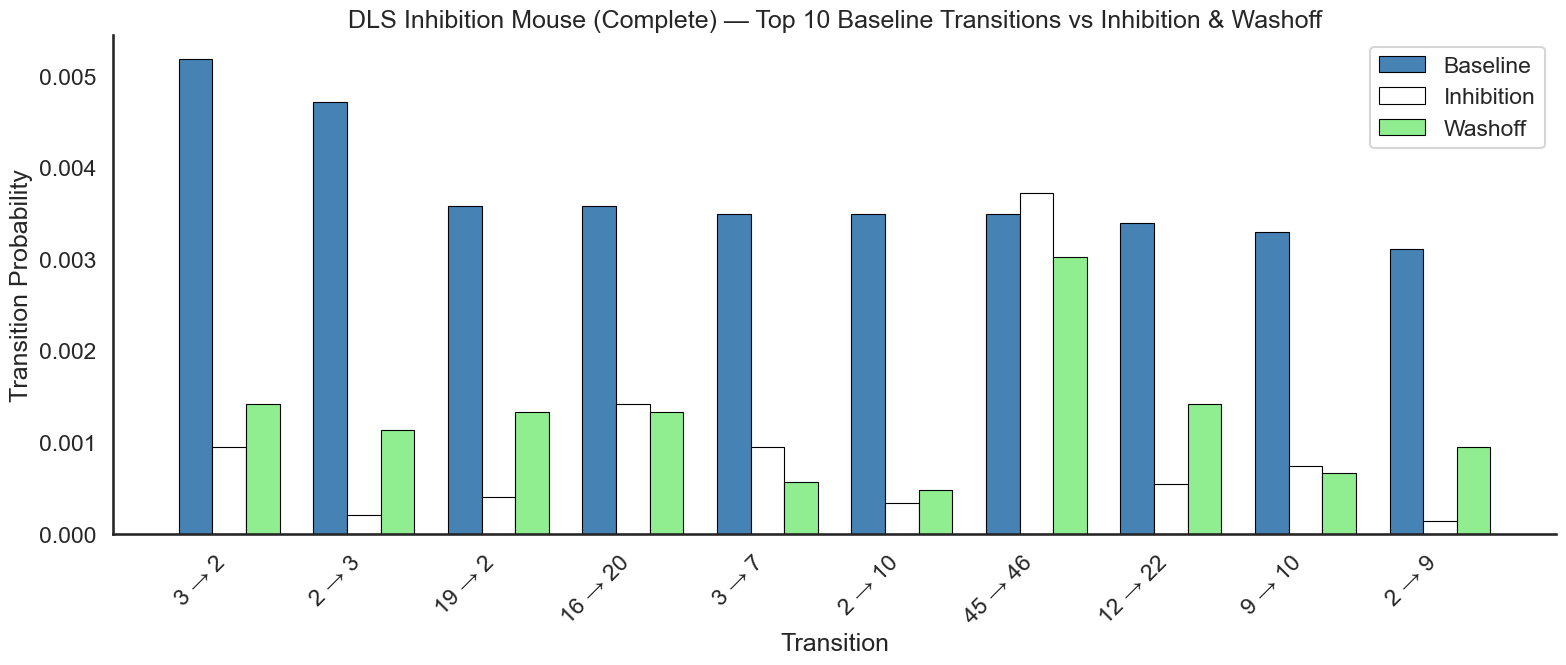


DLS Inhibition Mouse (Complete) — Top 10 Baseline Transitions
Transition  Baseline Probability  Inhibition Probability  Washoff Probability In Inhibition In Washoff
     3 → 2              0.005181                0.000947             0.001418           Yes        Yes
     2 → 3              0.004710                0.000203             0.001135           Yes        Yes
    19 → 2              0.003580                0.000406             0.001324           Yes        Yes
   16 → 20              0.003580                0.001420             0.001324           Yes        Yes
     3 → 7              0.003485                0.000947             0.000567           Yes        Yes
    2 → 10              0.003485                0.000338             0.000473           Yes        Yes
   45 → 46              0.003485                0.003719             0.003025           Yes        Yes
   12 → 22              0.003391                0.000541             0.001418           Yes        Yes
    9 → 10

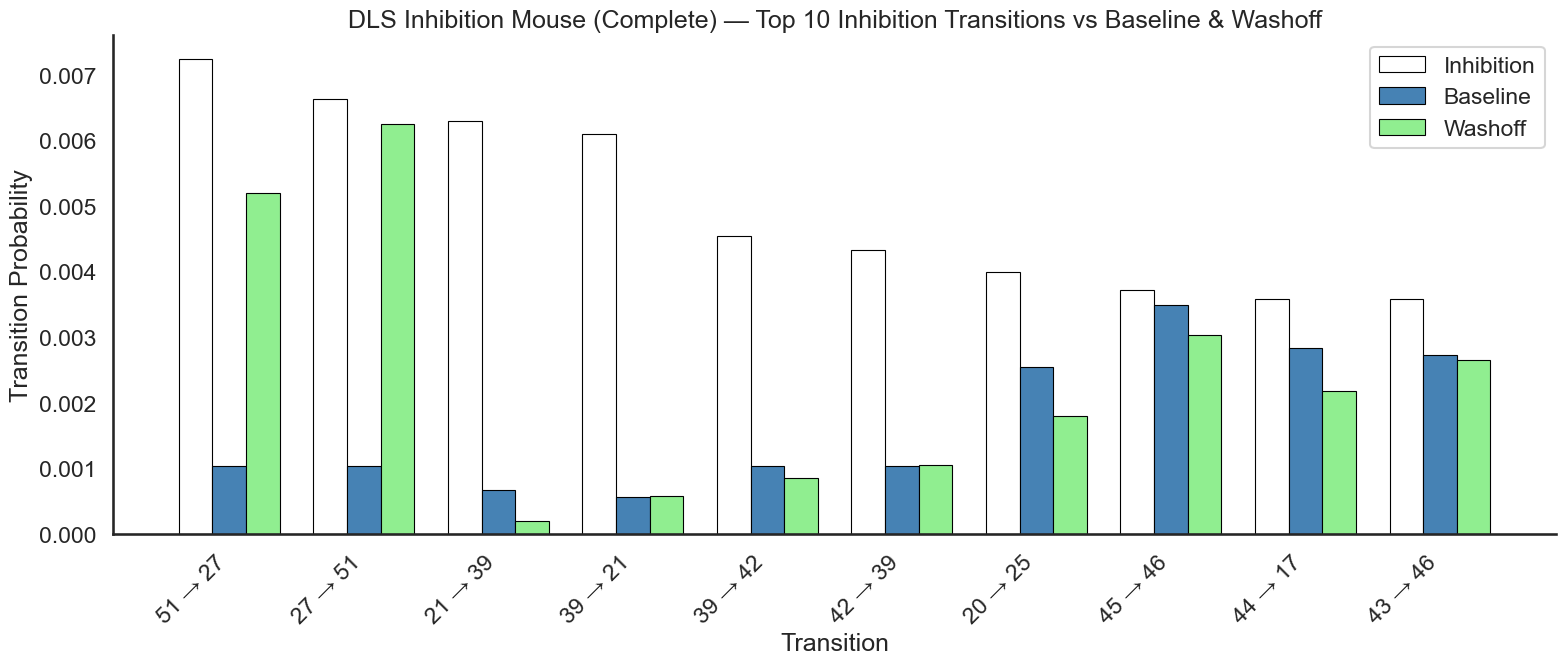


DLS Inhibition Mouse (Complete) — Top 10 Inhibition Transitions
Transition  Inhibition Probability  Baseline Probability  Washoff Probability In Baseline In Washoff
   51 → 27                0.007236              0.001036             0.005200         Yes        Yes
   27 → 51                0.006627              0.001036             0.006240         Yes        Yes
   21 → 39                0.006289              0.000659             0.000189         Yes        Yes
   39 → 21                0.006086              0.000565             0.000567         Yes        Yes
   39 → 42                0.004531              0.001036             0.000851         Yes        Yes
   42 → 39                0.004328              0.001036             0.001040         Yes        Yes
   20 → 25                0.003990              0.002543             0.001796         Yes        Yes
   45 → 46                0.003719              0.003485             0.003025         Yes        Yes
   44 → 17                

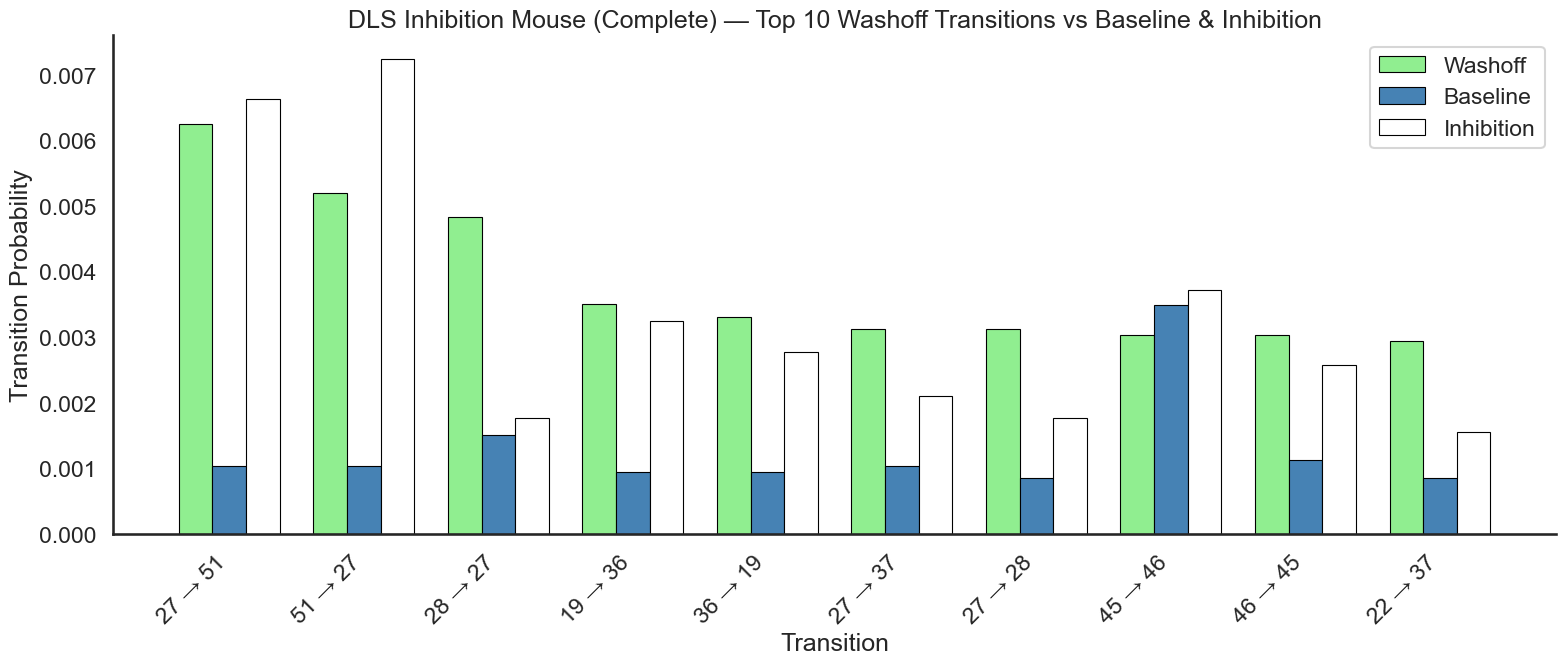


DLS Inhibition Mouse (Complete) — Top 10 Washoff Transitions
Transition  Washoff Probability  Baseline Probability  Inhibition Probability In Baseline In Inhibition
   27 → 51             0.006240              0.001036                0.006627         Yes           Yes
   51 → 27             0.005200              0.001036                0.007236         Yes           Yes
   28 → 27             0.004822              0.001507                0.001758         Yes           Yes
   19 → 36             0.003498              0.000942                0.003246         Yes           Yes
   36 → 19             0.003309              0.000942                0.002773         Yes           Yes
   27 → 37             0.003120              0.001036                0.002096         Yes           Yes
   27 → 28             0.003120              0.000848                0.001758         Yes           Yes
   45 → 46             0.003025              0.003485                0.003719         Yes           Yes
  

In [17]:
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_3d_vs_2d_top_transitions(df_mouse, mouse_name, top_n=10, reference="Baseline", save=True, path=f"{mouse_name}_Baseline_Reference_top_transitions.png")
    plot_3d_vs_2d_top_transitions(df_mouse, mouse_name, top_n=10, reference="Inhibition", save=True, path=f"{mouse_name}_Inhibition_Reference_top_transitions.png")
    plot_3d_vs_2d_top_transitions(df_mouse, mouse_name, top_n=10, reference="Washoff", save=True, path=f"{mouse_name}_Washoff_Reference_top_transitions.png")

In [18]:
def plot_cluster_counts(df_mouse, mouse_name, cluster_labels, save=False):
    """
    Plots two separate figures:
      - Figure 1: total cluster counts across all data
      - Figure 2: Baseline vs Inhibition vs Washoff side by side

    Parameters
    ----------
    df_mouse : pd.DataFrame
        DataFrame with columns: Timestamp, ClusterIdx, Arena.
    mouse_name : str
        Name of the mouse (used in title).
    cluster_labels : list of int
        List of cluster labels to include, e.g. [2, 4, 6, 8].
    """

    def summarize_cluster_counts(df):
        total_counts      = df.groupby("ClusterIdx").size().rename("Total Count")
        baseline_counts   = df[df["Arena"] == "Baseline"].groupby("ClusterIdx").size().rename("Baseline Count")
        inhibition_counts = df[df["Arena"] == "Inhibition"].groupby("ClusterIdx").size().rename("Inhibition Count")
        washoff_counts    = df[df["Arena"] == "Washoff"].groupby("ClusterIdx").size().rename("Washoff Count")

        df_out = (
            pd.concat([total_counts, baseline_counts, inhibition_counts, washoff_counts], axis=1)
            .fillna(0)
            .astype(int)
            .reset_index()
        )
        return df_out.sort_values("ClusterIdx").reset_index(drop=True)

    df_filtered = df_mouse[df_mouse["ClusterIdx"].isin(cluster_labels)]

    total_counts = (
        df_filtered["ClusterIdx"]
        .value_counts()
        .reindex(cluster_labels, fill_value=0)
    )

    arena_counts = {
        arena: (
            df_filtered[df_filtered["Arena"] == arena]["ClusterIdx"]
            .value_counts()
            .reindex(cluster_labels, fill_value=0)
        )
        for arena in ["Baseline", "Inhibition", "Washoff"]
    }

    color_map = {
        "Baseline":   "steelblue",
        "Inhibition": "white",
        "Washoff":    "lightgreen",
    }

    x         = np.arange(len(cluster_labels))
    bar_width = 0.25
    offsets   = np.linspace(-bar_width, bar_width, 3)
    xlabels   = [str(c) for c in cluster_labels]

    # --- plot 1: total counts ---
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x, total_counts.values, width=0.6, color="steelblue",
           edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Count")
    ax.set_title(f"{mouse_name} — Cluster Counts (All Data)")
    sns.despine()
    plt.tight_layout()
    if save:
        plt.savefig(f"{mouse_name}_Cluster_Counts_All.png", dpi=300)
    plt.show()

    # --- plot 2: baseline vs inhibition vs washoff ---
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, (arena, offset) in enumerate(zip(["Baseline", "Inhibition", "Washoff"], offsets)):
        ax.bar(x + offset, arena_counts[arena].values, width=bar_width,
               label=arena, color=color_map[arena], edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Count")
    ax.set_title(f"{mouse_name} — Cluster Counts (Baseline vs Inhibition vs Washoff)")
    ax.legend()
    sns.despine()
    plt.tight_layout()
    if save:
        plt.savefig(f"{mouse_name}_Cluster_Counts_Conditions.png", dpi=300)
    plt.show()

    summarize_cluster_counts(df_mouse).to_csv(f"{mouse_name}_Cluster_Counts.csv", index=False)

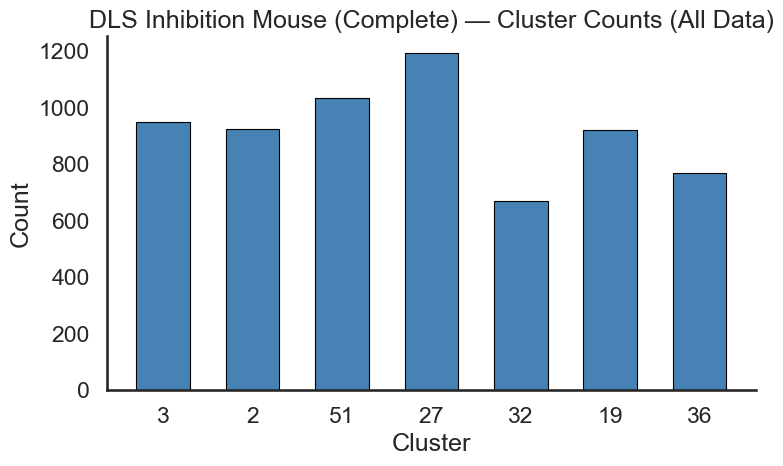

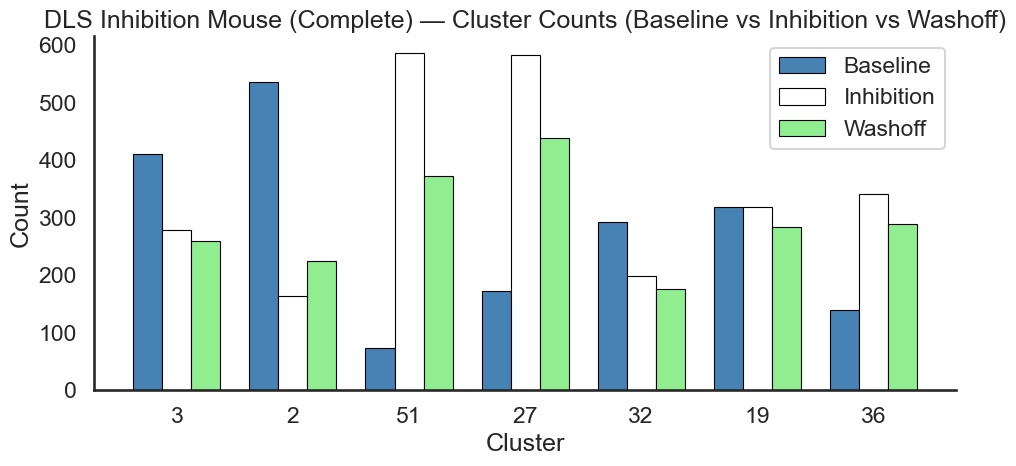

In [19]:
cluster_labels = [3, 2, 51, 27, 32, 19, 36]
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_cluster_counts(df_mouse, mouse_name, cluster_labels, save=True)

In [20]:
def plot_transition_probability_change(df_mouse, mouse_name, top_n=10, reference="Baseline", save=False, path=None):
    """
    Gets top N transitions from the reference condition, then plots % change
    for all other conditions as grouped bars side by side.

    Any of the three arenas (Baseline, Inhibition, Washoff) can be the reference.
    The remaining two are plotted as comparison bars.

    Parameters
    ----------
    reference : str
        "Baseline", "Inhibition", or "Washoff" — used to rank the top N transitions.
    """

    all_arenas = ["Baseline", "Inhibition", "Washoff"]

    if reference not in all_arenas:
        raise ValueError(f"reference must be one of {all_arenas}, got '{reference}'")

    comp_labels = [a for a in all_arenas if a != reference]  # the other two

    # --- pool transitions per arena ---
    group_trans = {}
    for arena in all_arenas:
        df_arena = df_mouse[df_mouse["Arena"] == arena].copy()
        combined = Counter()
        combined.update(pooled_transitions(df_arena, include_self_transitions=False))
        group_trans[arena] = dict(combined)

    # --- normalize to probabilities ---
    def to_probs(trans):
        total = sum(trans.values())
        if total == 0:
            return {}
        return {k: v / total for k, v in trans.items()}

    probs = {arena: to_probs(group_trans[arena]) for arena in all_arenas}

    if len(probs[reference]) == 0:
        print(f"No {reference} transitions for {mouse_name}")
        return

    # --- get top N transitions by reference probability ---
    top_transitions = sorted(probs[reference], key=probs[reference].get, reverse=True)[:top_n]

    labels   = [f"{c1} → {c2}" for (c1, c2) in top_transitions]
    vals_ref = [probs[reference].get(t, 0) for t in top_transitions]
    vals_comp = {c: [probs[c].get(t, 0) for t in top_transitions] for c in comp_labels}

    # --- compute % change per comparison ---
    def pct_change(vals_r, vals_c):
        return [
            ((vc - vr) / vr * 100) if vr > 0 else float("nan")
            for vr, vc in zip(vals_r, vals_c)
        ]

    pct_changes = {c: pct_change(vals_ref, vals_comp[c]) for c in comp_labels}

    # --- color scheme per comparison ---
    comp_colors = {
        comp_labels[0]: ("steelblue", "tomato"),      # positive / negative
        comp_labels[1]: ("lightgreen", "lightsalmon"), # positive / negative
    }

    # --- plot ---
    x         = np.arange(len(labels))
    bar_width = 0.35
    offsets   = [-bar_width / 2, bar_width / 2]

    fig, ax = plt.subplots(figsize=(16, 7))

    for i, comp in enumerate(comp_labels):
        changes     = pct_changes[comp]
        pos_color, neg_color = comp_colors[comp]
        bar_colors  = [
            pos_color if (not np.isnan(d) and d >= 0) else neg_color
            for d in changes
        ]

        ax.bar(x + offsets[i], changes, width=bar_width, color=bar_colors,
               edgecolor="black", linewidth=0.8, label=f"vs {comp}")

        # --- annotate undefined % changes ---
        for j, (d, vr) in enumerate(zip(changes, vals_ref)):
            if np.isnan(d):
                ax.text(x[j] + offsets[i], 0.05, "n/a\n(ref=0)",
                        ha="center", va="bottom", fontsize=7, color="gray")

    # --- zero reference line ---
    ax.axhline(0, color="black", linewidth=0.9, linestyle="--")

    # --- legend proxy patches ---
    from matplotlib.patches import Patch
    legend_elements = []
    for comp in comp_labels:
        pos_color, neg_color = comp_colors[comp]
        legend_elements += [
            Patch(facecolor=pos_color, edgecolor="black", label=f"Increase in {comp}"),
            Patch(facecolor=neg_color, edgecolor="black", label=f"Decrease in {comp}"),
        ]
    ax.legend(handles=legend_elements, fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_xlabel("Transition")
    ax.set_ylabel(f"% Change vs {reference}")
    ax.set_title(f"{mouse_name} — % Change in Top {top_n} {reference} Transitions")

    sns.despine()
    plt.tight_layout()

    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- print table ---
    df_out = pd.DataFrame({
        "Transition":              labels,
        f"{reference} Probability": vals_ref,
        **{f"{c} Probability":     vals_comp[c]   for c in comp_labels},
        **{f"% Change vs {c}":     [f"{d:+.1f}%" if not np.isnan(d) else "n/a" for d in pct_changes[c]]
           for c in comp_labels},
        **{f"Direction vs {c}":    ["↑" if (not np.isnan(d) and d > 0) else ("↓" if (not np.isnan(d) and d < 0) else "=")
           for d in pct_changes[c]] for c in comp_labels},
    })
    print(f"\n{mouse_name} — % Change for Top {top_n} {reference} Transitions")
    print(df_out.to_string(index=False))

    return df_out

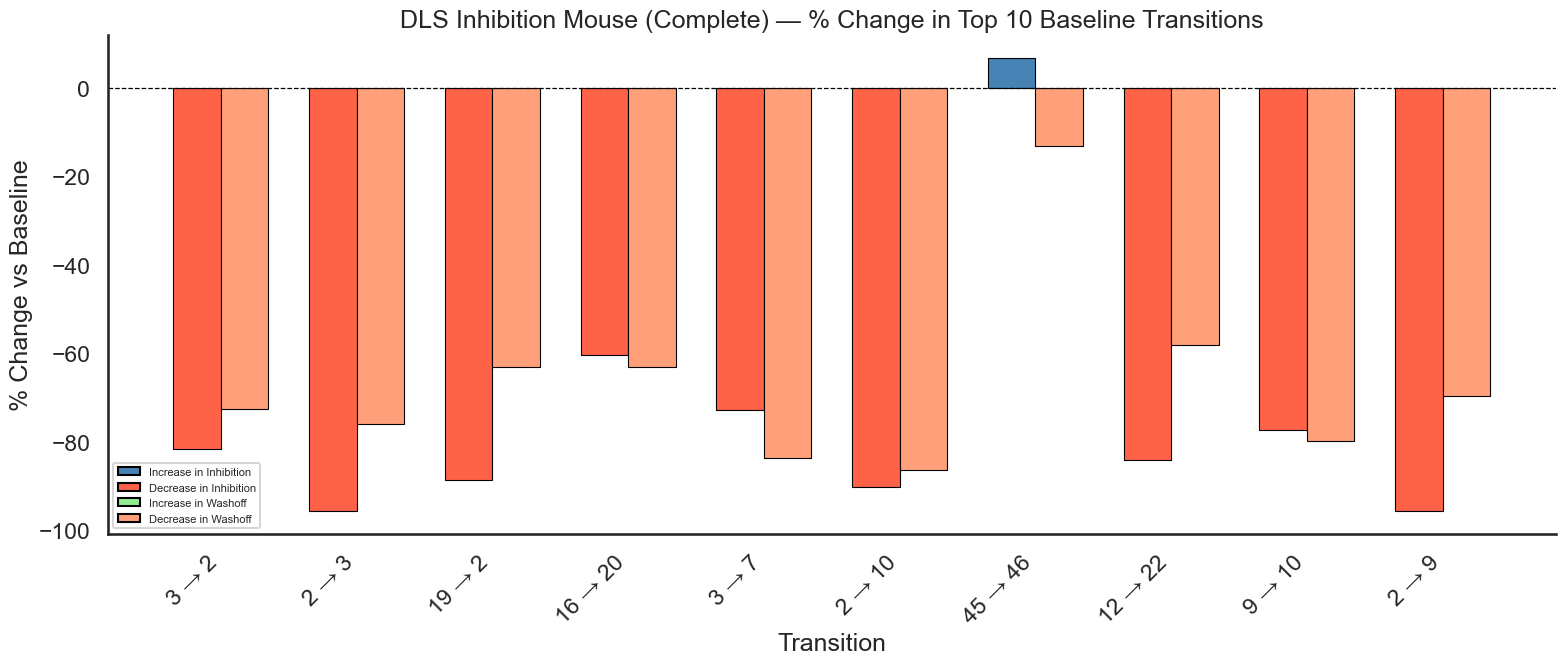


DLS Inhibition Mouse (Complete) — % Change for Top 10 Baseline Transitions
Transition  Baseline Probability  Inhibition Probability  Washoff Probability % Change vs Inhibition % Change vs Washoff Direction vs Inhibition Direction vs Washoff
     3 → 2              0.005181                0.000947             0.001418                 -81.7%              -72.6%                       ↓                    ↓
     2 → 3              0.004710                0.000203             0.001135                 -95.7%              -75.9%                       ↓                    ↓
    19 → 2              0.003580                0.000406             0.001324                 -88.7%              -63.0%                       ↓                    ↓
   16 → 20              0.003580                0.001420             0.001324                 -60.3%              -63.0%                       ↓                    ↓
     3 → 7              0.003485                0.000947             0.000567                 

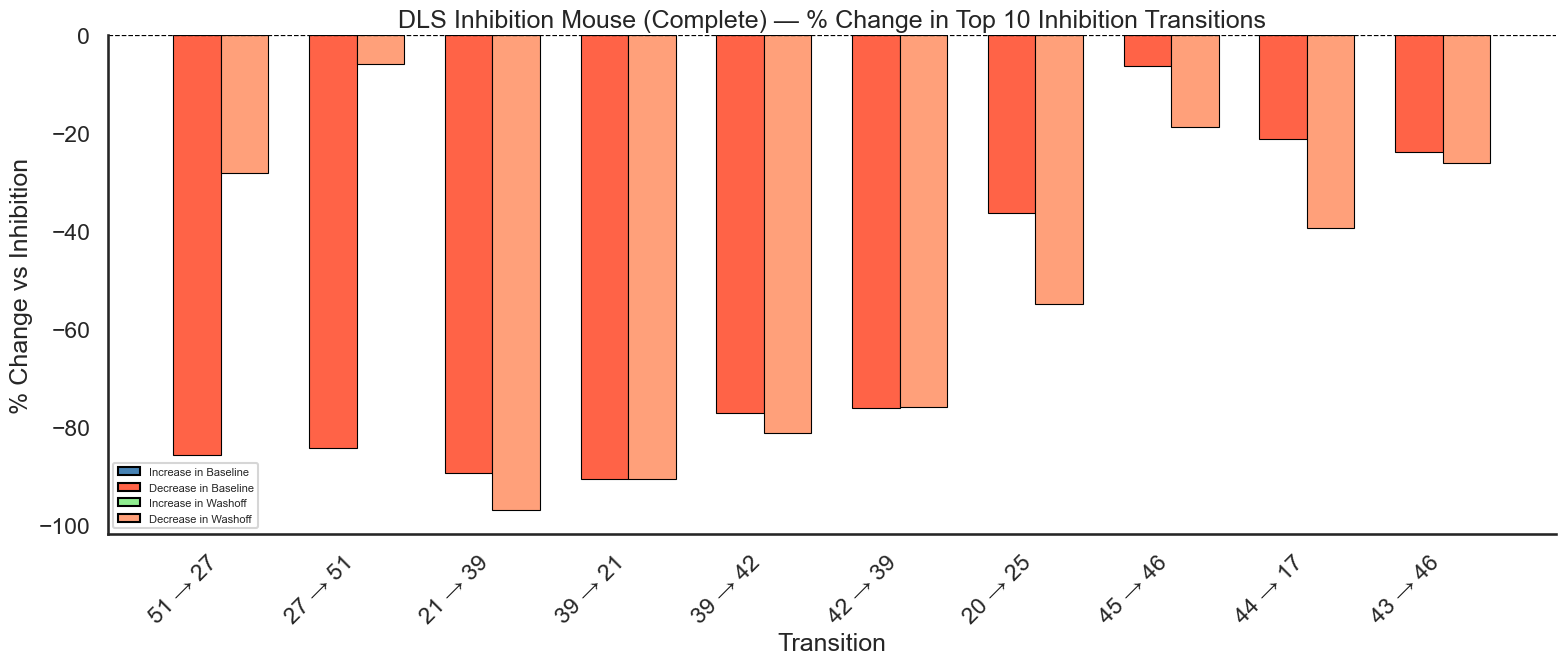


DLS Inhibition Mouse (Complete) — % Change for Top 10 Inhibition Transitions
Transition  Inhibition Probability  Baseline Probability  Washoff Probability % Change vs Baseline % Change vs Washoff Direction vs Baseline Direction vs Washoff
   51 → 27                0.007236              0.001036             0.005200               -85.7%              -28.1%                     ↓                    ↓
   27 → 51                0.006627              0.001036             0.006240               -84.4%               -5.8%                     ↓                    ↓
   21 → 39                0.006289              0.000659             0.000189               -89.5%              -97.0%                     ↓                    ↓
   39 → 21                0.006086              0.000565             0.000567               -90.7%              -90.7%                     ↓                    ↓
   39 → 42                0.004531              0.001036             0.000851               -77.1%              

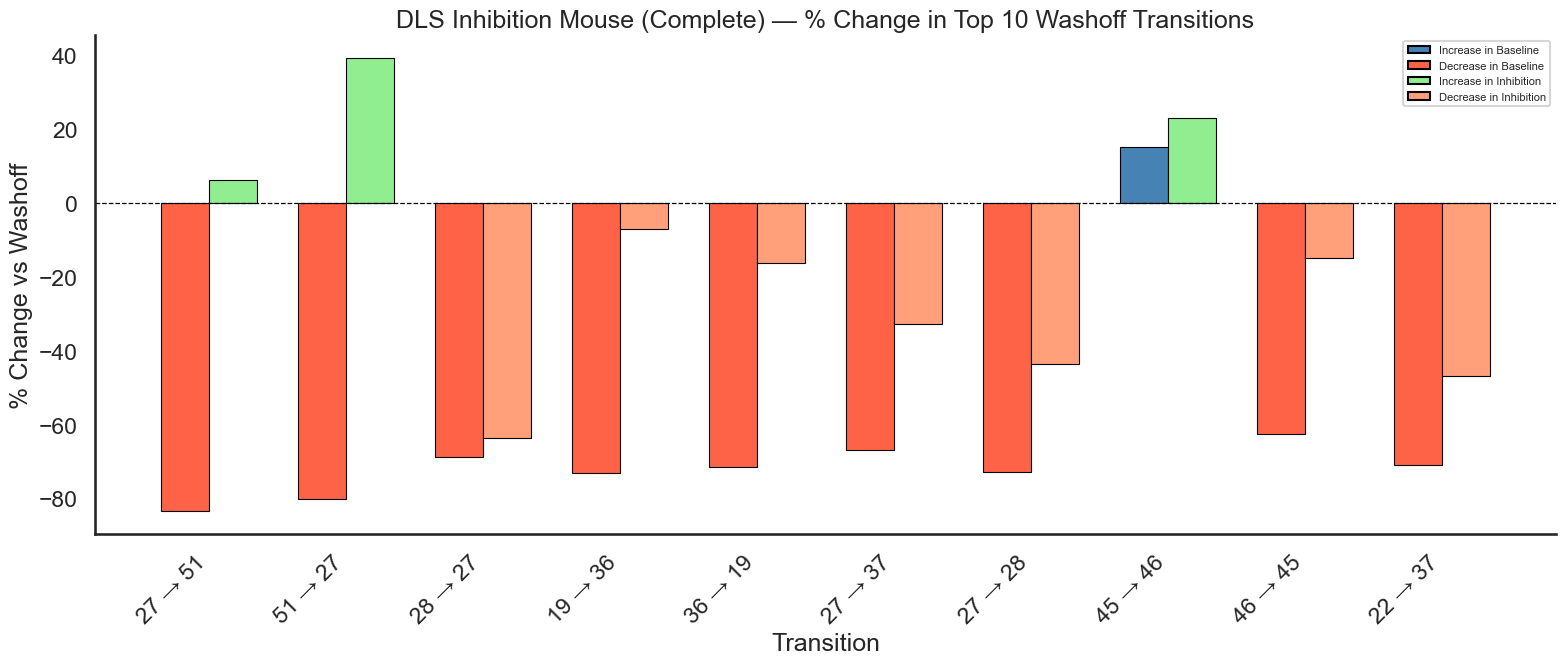


DLS Inhibition Mouse (Complete) — % Change for Top 10 Washoff Transitions
Transition  Washoff Probability  Baseline Probability  Inhibition Probability % Change vs Baseline % Change vs Inhibition Direction vs Baseline Direction vs Inhibition
   27 → 51             0.006240              0.001036                0.006627               -83.4%                  +6.2%                     ↓                       ↑
   51 → 27             0.005200              0.001036                0.007236               -80.1%                 +39.2%                     ↓                       ↑
   28 → 27             0.004822              0.001507                0.001758               -68.7%                 -63.5%                     ↓                       ↓
   19 → 36             0.003498              0.000942                0.003246               -73.1%                  -7.2%                     ↓                       ↓
   36 → 19             0.003309              0.000942                0.002773        

In [21]:
for mouse_name in df_all["Mouse"].unique():
    df_mouse = df_all[df_all["Mouse"] == mouse_name].copy()
    plot_transition_probability_change(df_mouse, mouse_name, top_n=10, reference="Baseline", save=True, path=f"{mouse_name}_Baseline_vs_Inhibition_transition_change.png")
    plot_transition_probability_change(df_mouse, mouse_name, top_n=10, reference="Inhibition", save=True, path=f"{mouse_name}_Inhibition_vs_Baseline_transition_change.png")
    plot_transition_probability_change(df_mouse, mouse_name, top_n=10, reference="Washoff", save=True, path=f"{mouse_name}_Inhibition_vs_Baseline_transition_change.png")

In [ ]:


df = pd.read_csv(r"C:\Users\gangliagurdian\Desktop\chemo_dms\Combined_Results\Results\test1\combined_results_dms_with_features.csv")
df["Condition"] = df["Folder_Name"].map({1.0: "Baseline", 2.0: "Inhibition"})

In [ ]:
def plot_cluster_accel(df, mouse_name, cluster_labels, save=False, path=None):

    df_filtered = df[df["Cluster"].isin(cluster_labels)].copy()

    means = (
        df_filtered
        .groupby(["Cluster", "Condition"])["TotAccelBA"]
        .mean()
        .reset_index()
    )

    x = np.arange(len(cluster_labels))
    bar_width = 0.45

    def safe_mean_accel(c, cond):
        row = means.query("Cluster == @c and Condition == @cond")["TotAccelBA"]
        return row.values[0] if len(row) > 0 else 0

    baseline_means   = [safe_mean_accel(c, "Baseline")   for c in cluster_labels]
    inhibition_means = [safe_mean_accel(c, "Inhibition") for c in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(x - bar_width / 2, baseline_means,   width=bar_width, label="Baseline",
           color="steelblue", edgecolor="black", linewidth=0.8)
    ax.bar(x + bar_width / 2, inhibition_means, width=bar_width, label="Inhibition",
           color="white",     edgecolor="black", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cluster_labels])
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Mean TotAccelBA")
    ax.set_title(f"{mouse_name} — Mean TotAccelBA by Cluster")
    ax.legend()

    sns.despine()
    plt.tight_layout()

    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- save CSV ---
    df_out = pd.DataFrame({
        "Cluster":                  [str(c) for c in cluster_labels],
        "Baseline Mean TotAccelBA":   baseline_means,
        "Inhibition Mean TotAccelBA": inhibition_means,
    })
    csv_path = path.replace(".png", "_accel.csv") if path else f"{mouse_name}_cluster_accel.csv"
    df_out.to_csv(csv_path, index=False)
    print(f"Saved accel CSV to {csv_path}")

    return df_out


def plot_cluster_dwell_time(df, mouse_name, cluster_labels, save=False, path=None):

    def compute_dwell(df_cond):
        df_cond = df_cond.sort_values("Timestamp").reset_index(drop=True)

        dwells = []
        i = 0
        while i < len(df_cond):
            current_cluster = df_cond.loc[i, "Cluster"]
            start_time      = df_cond.loc[i, "Timestamp"]

            j = i + 1
            while j < len(df_cond) and df_cond.loc[j, "Cluster"] == current_cluster:
                j += 1

            end_time     = df_cond.loc[j - 1, "Timestamp"]
            duration_sec = end_time - start_time

            dwells.append({"Cluster": current_cluster, "Dwell_s": duration_sec})
            i = j

        return pd.DataFrame(dwells)

    records = []
    for condition in ["Baseline", "Inhibition"]:
        df_cond = df[df["Condition"] == condition].copy()
        if df_cond.empty:
            continue
        dwell_df = compute_dwell(df_cond)
        dwell_df["Condition"] = condition
        records.append(dwell_df)

    if not records:
        print(f"No dwell data found for {mouse_name}")
        return

    all_dwells = pd.concat(records, ignore_index=True)
    all_dwells = all_dwells[all_dwells["Cluster"].isin(cluster_labels)]

    means = (
        all_dwells
        .groupby(["Cluster", "Condition"])["Dwell_s"]
        .mean()
        .reset_index()
    )

    x = np.arange(len(cluster_labels))
    bar_width = 0.35

    def safe_mean(c, cond):
        row = means.query("Cluster == @c and Condition == @cond")["Dwell_s"]
        return row.values[0] if len(row) > 0 else 0

    baseline_dwells   = [safe_mean(c, "Baseline")   for c in cluster_labels]
    inhibition_dwells = [safe_mean(c, "Inhibition") for c in cluster_labels]

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.bar(x - bar_width / 2, baseline_dwells,   width=bar_width, label="Baseline",
           color="steelblue", edgecolor="black", linewidth=0.8)
    ax.bar(x + bar_width / 2, inhibition_dwells, width=bar_width, label="Inhibition",
           color="white",     edgecolor="black", linewidth=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in cluster_labels])
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Mean Dwell Time (s)")
    ax.set_title(f"{mouse_name} — Mean Dwell Time by Cluster")
    ax.legend()

    sns.despine()
    plt.tight_layout()

    if save and path:
        plt.savefig(path, dpi=300)
    plt.show()

    # --- save CSV ---
    df_out = pd.DataFrame({
        "Cluster":                    [str(c) for c in cluster_labels],
        "Baseline Mean Dwell (s)":    baseline_dwells,
        "Inhibition Mean Dwell (s)":  inhibition_dwells,
    })
    csv_path = path.replace(".png", "_dwell.csv") if path else f"{mouse_name}_cluster_dwell.csv"
    df_out.to_csv(csv_path, index=False)
    print(f"Saved dwell CSV to {csv_path}")

    return df_out

In [ ]:
cluster_labels = [2, 7, 37, 21, 4, 2, 16, 17]
mouse_name = "DMS Inhibition Mouse"
plot_cluster_accel(df, mouse_name, cluster_labels, save=True, path=f"{mouse_name}_TotAccelBA.png")
plot_cluster_dwell_time(df, mouse_name, cluster_labels, save=True, path=f"{mouse_name}_Dwell_Time.png")